# **Import Libraries**

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import numpy as np

from matplotlib.patches import Ellipse

---
# **Load Dataset**

In [3]:
# Generate some data
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
X = X[:, ::-1] # flip axes for better plotting

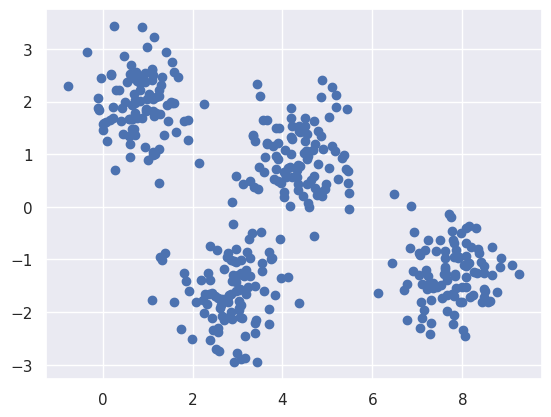

In [4]:
plt.scatter(X[:, 0], X[:, 1]);

---
# **`draw_ellipse` and `plot_gmm` Functions**

In [ ]:
def draw_ellipse(position, covariance, ax=None, **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()
    
    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)
    
    # Draw the Ellipse
    for nsig in range(1, 4):
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))


def plot_gmm(gmm, X, label=True, ax=None):
    ax = ax or plt.gca()
    labels = gmm.predict(X)
    if label:
        ax.scatter(X[:, 0], X[:, 1], c=labels, s=40, cmap='viridis', zorder=2)
    else:
        ax.scatter(X[:, 0], X[:, 1], s=40, zorder=2)
    ax.axis('equal')
    
    w_factor = 0.2 / gmm.weights_.max()
    for pos, covar, w in zip(gmm.means_, gmm.covariances_, gmm.weights_):
        draw_ellipse(pos, covar, ax=ax, alpha=w * w_factor)

---
# KMeans Clustering 

This section applies the KMeans clustering algorithm to the synthetic dataset `X`.  
- The number of clusters is set to 4, based on the visual inspection of the scatter plot.
- After fitting the model, each data point is assigned a cluster label (`labels_kmeans`).
- The results are visualized using a scatter plot, where each point is colored according to its assigned cluster.
- This provides a baseline clustering result for comparison with the Gaussian Mixture Model (GMM) approach in the next section.

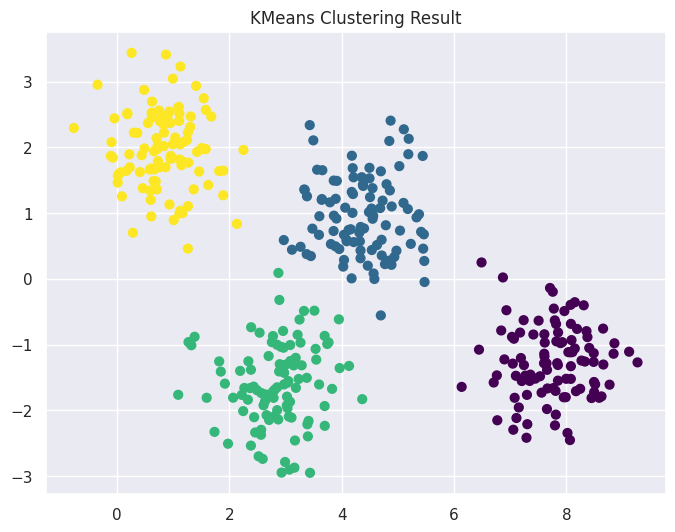

In [9]:
# KMeans clustering and visualization
from sklearn.cluster import KMeans

# Fit KMeans with 4 clusters (based on scatter plot)
kmeans = KMeans(n_clusters=4, random_state=0)
labels_kmeans = kmeans.fit_predict(X)

# Plot KMeans result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_kmeans, s=40, cmap='viridis')
plt.title('KMeans Clustering Result')
plt.show()

---
# Gaussian Mixture Model (GMM) Clustering 

This section applies the Gaussian Mixture Model (GMM) clustering algorithm to the synthetic dataset `X`.

- The GMM is initialized with 4 components (clusters), matching the number used in KMeans.
- After fitting the model, each data point is assigned a cluster label (`gmm_labels`).
- The probability matrix (`probs`) contains the probability of each point belonging to each cluster.
- A scatter plot visualizes the GMM clustering result, with point sizes proportional to the maximum cluster membership probability.

In [12]:
# Gaussian Mixture Model
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0)
gmm.fit(X)
gmm_labels = gmm.predict(X)

# Probability matrix for each point
probs = gmm.predict_proba(X)
probs

array([[4.69238090e-01, 5.30761633e-01, 2.76240973e-07, 1.75162717e-22],
       [1.97106146e-17, 9.22826700e-10, 9.99999999e-01, 4.71110558e-15],
       [2.34875746e-14, 2.09565089e-09, 9.99999998e-01, 3.07981606e-17],
       ...,
       [2.32520153e-36, 4.50722543e-08, 2.15904343e-08, 9.99999933e-01],
       [2.87688722e-15, 5.36220515e-01, 4.63399146e-01, 3.80339560e-04],
       [1.10349655e-46, 1.19335720e-11, 6.20815080e-14, 1.00000000e+00]])

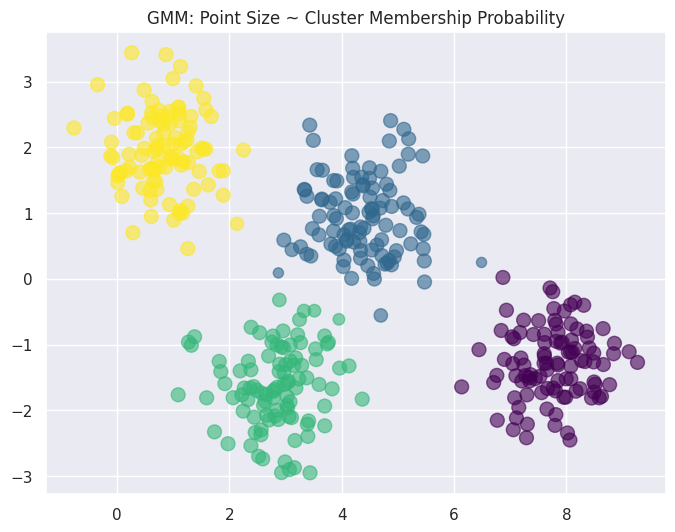

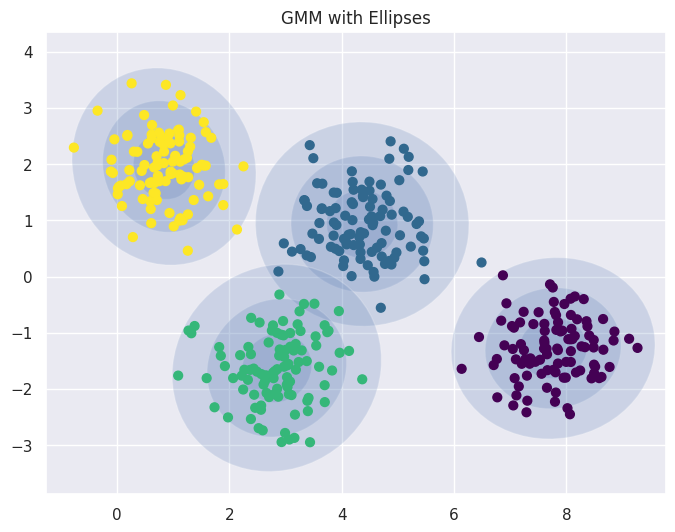

In [ ]:
# Visualize points with size proportional to max probability
plt.figure(figsize=(8, 6))
sizes = 100 * probs.max(axis=1)  # scale for better visualization
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, s=sizes, cmap='viridis', alpha=0.6)
plt.title('GMM: Point Size ~ Cluster Membership Probability')
plt.show()

# Use the provided plot_gmm function to visualize GMM ellipses
plt.figure(figsize=(8, 6))
plot_gmm(gmm, X)
plt.title('GMM with Ellipses')
plt.show()